In [96]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [97]:
DATA_DIR = "../data/raw"
OUTPUT_FIG_DIR = "../output/figures"

In [98]:
customers = pd.read_csv(os.path.join(DATA_DIR, "customers.csv"))
geography = pd.read_csv(os.path.join(DATA_DIR, "geography.csv"))
inventory = pd.read_csv(os.path.join(DATA_DIR, "inventory.csv"))
order_items = pd.read_csv(os.path.join(DATA_DIR, "order_items.csv"), dtype={"promo_id_2": str})
orders = pd.read_csv(os.path.join(DATA_DIR, "orders.csv"))
payments = pd.read_csv(os.path.join(DATA_DIR, "payments.csv"))
products = pd.read_csv(os.path.join(DATA_DIR, "products.csv"))
promotions = pd.read_csv(os.path.join(DATA_DIR, "promotions.csv"))
returns = pd.read_csv(os.path.join(DATA_DIR, "returns.csv"))
reviews = pd.read_csv(os.path.join(DATA_DIR, "reviews.csv"))
sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"))
shipments = pd.read_csv(os.path.join(DATA_DIR, "shipments.csv"))
web_traffic = pd.read_csv(os.path.join(DATA_DIR, "web_traffic.csv"))

# **1. Lớp Master**
## **1.1. Products**

In [99]:
products.head()

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


In [100]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   object 
 2   category      2412 non-null   object 
 3   segment       2412 non-null   object 
 4   size          2412 non-null   object 
 5   color         2412 non-null   object 
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 150.9+ KB


- Không có giá trị null

### *Ép kiểu dữ liệu*

In [101]:
text_cols = ['product_name', 'category', 'segment', 'size', 'color']
for col in text_cols:
    products[col] = products[col].astype(str).str.strip()

### *Kiểm tra trùng lặp và logic*

In [102]:
assert products.duplicated('product_id').sum() == 0, "Có duplicate product_id!"
assert products.duplicated().sum() == 0, "Có duplicate rows!"
print("- Không có lỗi trùng lặp")

# Kiểm tra logic giá trị dương (Giá bán và giá vốn không thể âm)
assert (products['price'] > 0).all(), "LỖI: Phát hiện sản phẩm có giá bán <= 0!"
assert (products['cogs'] > 0).all(), "LỖI: Phát hiện sản phẩm có giá vốn <= 0!"
print("- Không có lỗi vi phạm logic giá trị dương")

# Ràng buộc đề bài: cogs < price
assert (products['cogs'] >= products['price']).sum() == 0, "Vi phạm cogs >= price!"
print("- Tất cả cogs < price")

# Giá trị hợp lệ của categorical columns
valid_categories = {'Streetwear', 'Casual', 'Outdoor', 'GenZ'}
valid_segments   = {'Everyday', 'Performance', 'Balanced', 'Standard',
                    'All-weather', 'Premium', 'Trendy', 'Activewear'}
valid_sizes      = {'S', 'M', 'L', 'XL'}

assert (~products['category'].isin(valid_categories)).sum() == 0, "Có category không hợp lệ!"
assert (~products['segment'].isin(valid_segments)).sum() == 0, "Có segment không hợp lệ!"
assert (~products['size'].isin(valid_sizes)).sum() == 0, "Có size không hợp lệ!"
print("- Tất cả category, segment, size hợp lệ")

- Không có lỗi trùng lặp
- Không có lỗi vi phạm logic giá trị dương
- Tất cả cogs < price
- Tất cả category, segment, size hợp lệ


### *Kiểm tra lỗi nhập liệu*

In [103]:
products['profit_margin'] = (products['price'] - products['cogs']) / products['price']

# Margin nằm trong khoảng [5%, 50%] — đúng với thực tế dữ liệu
# Min=5% là giá trị sàn thiết kế có chủ đích, max=~50%
assert (products['profit_margin'] < 0).sum() == 0, "Có margin âm!"
print("- Tất cả profit_margin >= 0")

# Kiểm tra giá lệch > 3 std trong cùng segment — ghi nhận, không xử lý
products['price_zscore_in_segment'] = products.groupby('segment')['price'].transform(
    lambda x: (x - x.mean()) / x.std()
)
suspicious = products[products['price_zscore_in_segment'].abs() > 3]
print(f"- {len(suspicious)} sản phẩm giá lệch > 3 std trong segment")
print(f"    → Margin hợp lệ ({suspicious['profit_margin'].min():.2f}–{suspicious['profit_margin'].max():.2f}), giữ nguyên")

# Bỏ cột zscore — chỉ dùng để kiểm tra, không cần lưu
products = products.drop(columns=['price_zscore_in_segment'])

- Tất cả profit_margin >= 0
- 6 sản phẩm giá lệch > 3 std trong segment
    → Margin hợp lệ (0.05–0.47), giữ nguyên


- Bằng cách so sánh trong cùng một Segment (ví dụ: cùng là dòng áo phông "Everyday"), nếu một sản phẩm vọt lên mức $Z > 3$, khả năng cao đó là lỗi của con người chứ không phải do chiến lược giá. Tuy nhiên trong trường hợp này, ta thấy `profit_margin` của 6 sản phẩm này vẫn nằm trong khoảng hợp lệ [5% - 50%] nên ta giữ nguyên các sản phẩm này

### *Feature Engineering*

In [104]:
# Đã tạo profit_margin

# price_tier: phân nhóm giá để phân tích trong EDA
products['price_tier'] = pd.cut(
    products['price'],
    bins=[0, 1000, 5000, 15000, float('inf')],
    labels=['Budget', 'Mid-range', 'Premium', 'Luxury']
)

### *Xuất file*

In [105]:
output_path = "../data/processed/pre_processed/products_preprocessed.csv"
products.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/products_preprocessed.csv


## **1.2. Customers**

In [106]:
customers.head()

,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


In [107]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121930 entries, 0 to 121929
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   customer_id          121930 non-null  int64 
 1   zip                  121930 non-null  int64 
 2   city                 121930 non-null  object
 3   signup_date          121930 non-null  object
 4   gender               121930 non-null  object
 5   age_group            121930 non-null  object
 6   acquisition_channel  121930 non-null  object
dtypes: int64(2), object(5)
memory usage: 6.5+ MB


- Không có giá trị null

### *Ép kiểu dữ liệu*

In [108]:
customers['customer_id'] = customers['customer_id'].astype(str).str.strip()

# Chuyển sang str và đảm bảo độ dài đồng nhất (ví dụ 5 chữ số)
# Nếu mã ZIP là 123, zfill(5) sẽ biến nó thành '00123'
customers['zip'] = customers['zip'].astype(str).str.zfill(5)

customers['signup_date'] = pd.to_datetime(customers['signup_date'])

### *Kiểm tra trùng lặp và lỗi logic*

In [109]:
assert customers.duplicated().sum() == 0, "Có duplicate rows!"
assert customers.duplicated('customer_id').sum() == 0, "Có duplicate customer_id!"
print("- Không có duplicate")

# signup_date không được sau 2022-12-31
assert (customers['signup_date'] > '2022-12-31').sum() == 0, "Có signup_date sau 2022-12-31!"
print("- Tất cả signup_date không vượt quá 2022-12-31")

- Không có duplicate
- Tất cả signup_date không vượt quá 2022-12-31


### *Feature Engineering*

In [110]:
# Thời gian đăng ký
customers['signup_year']  = customers['signup_date'].dt.year
customers['signup_month'] = customers['signup_date'].dt.month

# Cohort theo quý đăng ký — dùng cho phân tích retention trong EDA
customers['signup_cohort'] = customers['signup_date'].dt.to_period('Q').astype(str)

- Biến `signup_cohort` cho phép phân tích cohort analysis — so sánh hành vi mua hàng của nhóm khách đăng ký cùng quý. Đây là phân tích thường xuất hiện trong EDA E-commerce.

### *Xuất file*

In [111]:
output_path = "../data/processed/pre_processed/customers_preprocessed.csv"
customers.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/customers_preprocessed.csv


## **1.3. Promotions**

In [112]:
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [113]:
promotions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   promo_id             50 non-null     object 
 1   promo_name           50 non-null     object 
 2   promo_type           50 non-null     object 
 3   discount_value       50 non-null     float64
 4   start_date           50 non-null     object 
 5   end_date             50 non-null     object 
 6   applicable_category  10 non-null     object 
 7   promo_channel        50 non-null     object 
 8   stackable_flag       50 non-null     int64  
 9   min_order_value      50 non-null     int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 4.0+ KB


### *Kiểm tra dữ liệu thiếu*

In [114]:
# Kiểm tra chi tiết dữ liệu thiếu
missing = promotions.isnull().sum()
missing_pct = missing / len(promotions) * 100
missing_promotions = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_pct.round(2)})
missing_promotions

,Missing Values,Percentage (%)
promo_id,0,0.0
promo_name,0,0.0
promo_type,0,0.0
discount_value,0,0.0
start_date,0,0.0
end_date,0,0.0
applicable_category,40,80.0
promo_channel,0,0.0
stackable_flag,0,0.0
min_order_value,0,0.0


- Ta thấy các giá trị thiếu tập trung ở cột `applicable_category` -> Các giá trị null này là hợp lý vì mã giảm giá được áp dụng cho toàn bộ danh mục (theo đề bài)
- Vì vậy, nhóm quyết định fill NaN = 'All'

In [115]:
promotions['applicable_category'] = promotions['applicable_category'].fillna('All')

### *Chuẩn hóa văn bản và ép kiểu dữ liệu*

In [116]:
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

text_cols = ['promo_name', 'promo_type', 'applicable_category', 'promo_channel']
for col in text_cols:
    promotions[col] = promotions[col].astype(str).str.strip()

### *Kiểm tra duplicate và lỗi logic*

In [117]:
assert promotions.duplicated().sum() == 0, "Có duplicate rows!"
assert promotions.duplicated('promo_id').sum() == 0, "Có duplicate promo_id!"
print("- Không có duplicate")

assert (promotions['end_date'] < promotions['start_date']).sum() == 0, "Có end_date trước start_date!"
print("- Tất cả end_date >= start_date")

assert (promotions['discount_value'] <= 0).sum() == 0, "Có discount_value <= 0!"
print("- Tất cả discount_value > 0")

assert (promotions['min_order_value'] < 0).sum() == 0, "Có min_order_value < 0!"
print("- Tất cả min_order_value >= 0")

# percentage không được > 100%
pct_over_100 = promotions[(promotions['promo_type'] == 'percentage') & (promotions['discount_value'] > 100)]
assert len(pct_over_100) == 0, "Có percentage discount > 100%!"
print("- Tất cả percentage discount <= 100%")

assert promotions['stackable_flag'].isin([0, 1]).all(), "Có stackable_flag không phải 0/1!"
print("- stackable_flag chỉ chứa 0 và 1")

- Không có duplicate
- Tất cả end_date >= start_date
- Tất cả discount_value > 0
- Tất cả min_order_value >= 0
- Tất cả percentage discount <= 100%
- stackable_flag chỉ chứa 0 và 1


### *Feature Engineering*

In [118]:
# Số ngày diễn ra chiến dịch
promotions['promo_duration_days'] = (promotions['end_date'] - promotions['start_date']).dt.days

### *Xuất file*

In [119]:
output_path = "../data/processed/pre_processed/promotions_preprocessed.csv"
promotions.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/promotions_preprocessed.csv


## **1.4. Geography**

In [120]:
geography.head()

,zip,city,region,district
0,15201,Hai Phong,East,District #13
1,15202,Phu Ly,East,District #13
2,15203,Viet Tri,East,District #13
3,15204,Bac Giang,East,District #13
4,15205,Bac Giang,East,District #13


In [121]:
geography.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39948 entries, 0 to 39947
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   zip       39948 non-null  int64 
 1   city      39948 non-null  object
 2   region    39948 non-null  object
 3   district  39948 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


- Không có giá trị null

### *Ép kiểu dữ liệu*

In [122]:
# Chuyển zip sang str và đảm bảo độ dài đồng nhất (5 chữ số)
geography['zip'] = geography['zip'].astype(str).str.zfill(5)

### *Kiểm tra trùng lặp và duplicate*

In [123]:
assert geography.duplicated().sum() == 0, "Có duplicate rows!"
assert geography.duplicated('zip').sum() == 0, "Có duplicate zip!"
print("- Không có duplicate")


- Không có duplicate


### *Xuất file*

In [124]:
output_path = "../data/processed/pre_processed/geography_preprocessed.csv"
geography.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/geography_preprocessed.csv


# **2. Lớp Transaction**

## **2.1. Orders**

In [125]:
orders.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [126]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   order_id        646945 non-null  int64 
 1   order_date      646945 non-null  object
 2   customer_id     646945 non-null  int64 
 3   zip             646945 non-null  int64 
 4   order_status    646945 non-null  object
 5   payment_method  646945 non-null  object
 6   device_type     646945 non-null  object
 7   order_source    646945 non-null  object
dtypes: int64(3), object(5)
memory usage: 39.5+ MB


Ta thấy không có giá trị null

### *Ép kiểu dữ liệu*

In [127]:
# IDs thành chuỗi
for col in ['order_id', 'customer_id', 'zip']:
    orders[col] = orders[col].astype(str)

# Thời gian thành Datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])


### *Kiểm tra trùng lặp*

In [128]:
assert orders.duplicated('order_id').sum() == 0, "Có duplicate order_id!"
assert orders.duplicated().sum() == 0, "Có duplicate rows!"
print("- Không có duplicate")

- Không có duplicate


### *Kiểm tra logic*

In [129]:
valid_start = pd.Timestamp('2012-07-04')
valid_end   = pd.Timestamp('2022-12-31')
invalid_dates = orders[
    (orders['order_date'] < valid_start) | (orders['order_date'] > valid_end)
]
assert len(invalid_dates) == 0, f"Có {len(invalid_dates)} đơn ngoài khoảng thời gian!"
print("- Tất cả order_date nằm trong khoảng hợp lệ")

valid_statuses = {'created', 'paid', 'shipped', 'delivered', 'cancelled', 'returned'}
invalid_status = orders[~orders['order_status'].isin(valid_statuses)]
assert len(invalid_status) == 0, "Có order_status không hợp lệ!"
print("- Tất cả order_status hợp lệ")

- Tất cả order_date nằm trong khoảng hợp lệ
- Tất cả order_status hợp lệ


### *Feature Engineering*

In [130]:
orders['year']        = pd.to_datetime(orders['order_date']).dt.year
orders['month']       = pd.to_datetime(orders['order_date']).dt.month
orders['quarter']     = pd.to_datetime(orders['order_date']).dt.quarter
orders['day_of_week'] = pd.to_datetime(orders['order_date']).dt.dayofweek
orders['is_weekend']  = (orders['day_of_week'] >= 5).astype(int)

### *Xuất file*

In [131]:
output_path = "../data/processed/pre_processed/orders_preprocessed.csv"
orders.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/orders_preprocessed.csv


## **2.2. Order_Items**

In [132]:
order_items.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


In [133]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714669 entries, 0 to 714668
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   order_id         714669 non-null  int64  
 1   product_id       714669 non-null  int64  
 2   quantity         714669 non-null  int64  
 3   unit_price       714669 non-null  float64
 4   discount_amount  714669 non-null  float64
 5   promo_id         276316 non-null  object 
 6   promo_id_2       206 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 38.2+ MB


- Ta thấy dữ liệu thiếu tập trung ở `promo_id` và `promo_id_2`

### *Ép kiểu dữ liệu*

In [134]:
for col in ['order_id', 'product_id']:
    order_items[col] = order_items[col].astype(str)

### *Kiểm tra dữ liệu thiếu*

In [135]:
# Kiểm tra chi tiết dữ liệu thiếu
missing = order_items.isnull().sum()
missing_pct = missing / len(order_items) * 100
missing_order_items = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_pct.round(2)})
missing_order_items

,Missing Values,Percentage (%)
order_id,0,0.00
product_id,0,0.00
quantity,0,0.00
unit_price,0,0.00
discount_amount,0,0.00
promo_id,438353,61.34
promo_id_2,714463,99.97


- Đơn hàng có thể sử dụng mã giảm giá hoặc không, các đơn không sử dụng mã giảm giá dẫn đến promo_id, promo_id_2 mang giá trị null hoàn toàn là hợp lý. Vì vậy ta không sửa mà điền giá trị "NONE" cho các ô trống

In [136]:
order_items['promo_id'] = order_items['promo_id'].fillna('NONE')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('NONE')

print(f"Số dòng Null còn lại sau xử lý: {order_items.isnull().sum().sum()}")

Số dòng Null còn lại sau xử lý: 0


### *Kiểm tra Logic và Duplicate*

In [137]:
assert order_items.duplicated().sum() == 0, "Lỗi: Có dòng trùng lặp hoàn toàn!"
assert (order_items['quantity'] > 0).all(), "Lỗi: Có số lượng <= 0!"
assert (order_items['unit_price'] >= 0).all(), "Lỗi: Có giá bán bị âm!"
assert (order_items['discount_amount'] >= 0).all(), "Lỗi: Mức giảm giá bị âm!"
print("- Không có dòng bị trùng lặp hoàn toàn và gặp các lỗi logic cơ bản")

- Không có dòng bị trùng lặp hoàn toàn và gặp các lỗi logic cơ bản


### *Kiểm tra các dòng bị trùng cặp khóa `(order_id, product_id)`*

In [138]:
# Sử dụng keep=False để Pandas giữ lại tất cả các dòng thuộc nhóm bị trùng (cả dòng gốc lẫn dòng nhân bản)
dupes_mask = order_items.duplicated(subset=['order_id', 'product_id'], keep=False)

# Lọc ra các dòng bị trùng và lưu vào một DataFrame
df_duplicates = order_items[dupes_mask].copy()

# Sắp xếp theo order_id và product_id để các cặp trùng nằm liền kề nhau
df_duplicates_sorted = df_duplicates.sort_values(by=['order_id', 'product_id'])

print(f"- Tổng số dòng bị trùng lặp cặp (order_id, product_id): {len(df_duplicates_sorted)}")

# Hiển thị 10 dòng đầu tiên (5 cặp) kèm các cột quan trọng để so sánh giá và khuyến mãi
cols_to_show = ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id']
print("\n--- Danh sách các cặp trùng lặp ---")
display(df_duplicates_sorted[cols_to_show].head(10))

- Tổng số dòng bị trùng lặp cặp (order_id, product_id): 32

--- Danh sách các cặp trùng lặp ---


,order_id,product_id,quantity,unit_price,discount_amount,promo_id
99645,113379,786,6,694.34,0.00,NONE
99646,113379,786,1,699.37,0.00,NONE
12233,14280,976,1,4019.47,0.00,NONE
12234,14280,976,2,3937.99,0.00,NONE
189239,215525,1859,5,1896.11,0.00,NONE
189240,215525,1859,5,1897.20,0.00,NONE
190291,216740,791,8,793.10,0.00,NONE
190292,216740,791,5,825.52,0.00,NONE
214311,243342,777,7,1181.17,1653.64,PROMO-0010
214312,243342,777,5,1147.21,1147.21,PROMO-0010


- Ta thấy có tổng số dòng bị trùng lặp cặp khóa `order_id + product_id` là 32, tức có 16 trường hợp khách mua cùng 1 mã sản phẩm trong 1 đơn nhưng bị tách làm 2 dòng với 2 mức giá khác nhau. 
- Trong E-Commerce, khách bấm thêm vào giỏ 2 lần ở 2 mức giá khác nhau thì hệ thống ghi nhận thành 2 dòng riêng biệt. Vì vậy nhóm quyết định giữ nguyên để phản ánh đúng lịch sử mua hàng.

### *Feature Engineering cơ bản*

In [139]:
# Doanh thu gộp (Chưa trừ khuyến mãi)
order_items['gross_revenue'] = order_items['quantity'] * order_items['unit_price']

# Doanh thu thuần (Đã trừ tiền khuyến mãi)
order_items['net_revenue'] = order_items['gross_revenue'] - order_items['discount_amount']

# Biến cờ hiệu: Đơn hàng này CÓ giảm giá hay không? (1: Có, 0: Không)
order_items['is_discounted'] = (order_items['discount_amount'] > 0).astype(int)

# Thêm biến Tỷ lệ giảm giá
order_items['discount_percent'] = (order_items['discount_amount'] / order_items['gross_revenue'] * 100).fillna(0).round(2)

# Kiểm tra logic cuối: Không thể bán lỗ âm tiền (Giảm giá lớn hơn tổng tiền hàng)
assert (order_items['net_revenue'] >= 0).all(), "Lỗi: Giảm giá lớn hơn doanh thu gộp!"
print("Dữ liệu hoàn toàn hợp lệ về mặt Logic Doanh Thu.")

Dữ liệu hoàn toàn hợp lệ về mặt Logic Doanh Thu.


### *Xuất file*

In [140]:
output_path = "../data/processed/pre_processed/order_items_preprocessed.csv"
order_items.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/order_items_preprocessed.csv


## **2.3. Payments**

In [141]:
payments.head()

,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1


In [142]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646945 entries, 0 to 646944
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        646945 non-null  int64  
 1   payment_method  646945 non-null  object 
 2   payment_value   646945 non-null  float64
 3   installments    646945 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 19.7+ MB


- Không có giá trị null
- Có 646945 dòng, hoàn toàn khớp với bảng Orders, đảm bảo quan hệ 1-1

### *Ép kiểu dữ liệu*

In [143]:
payments['order_id'] = payments['order_id'].astype(str)

### *Kiểm tra trùng lặp và logic*

In [144]:
assert payments.duplicated().sum() == 0, "Lỗi: Có dòng trùng lặp hoàn toàn!"
assert payments.duplicated(subset=['order_id']).sum() == 0, "Lỗi: 1 Đơn hàng có nhiều lần thanh toán!"
assert (payments['payment_value'] > 0).all(), "Lỗi: Có giá trị thanh toán <= 0!"
assert (payments['installments'] >= 1).all(), "Lỗi: Số tháng trả góp < 1!"

# Kiểm tra logic COD: Không được phép trả góp (installments phải bằng 1)
cod_installment_error = payments[(payments['payment_method'] == 'cod') & (payments['installments'] > 1)]
assert len(cod_installment_error) == 0, f"Lỗi logic: Có {len(cod_installment_error)} đơn COD ghi nhận trả góp!"

print("- Không có dòng bị trùng lặp hoàn toàn, không có lỗi logic")

- Không có dòng bị trùng lặp hoàn toàn, không có lỗi logic


- Tuy nhiên ta thấy cột `payment_method` đã xuất hiện trong bảng `orders`, vì vậy nhóm tiến hành drop cột này để tránh lỗi dữ liệu khi gộp dữ liệu sau này.

In [145]:
payments = payments.drop(columns=['payment_method'])

### *Feature Engineering (Hành vi thanh toán)*

In [146]:
# Biến 1: Số tiền phải trả mỗi tháng (Average Installment Value)
# Cho biết "gánh nặng tài chính" hàng tháng của khách
payments['monthly_installment_value'] = (payments['payment_value'] / payments['installments']).round(2)

# Biến 2: Có đang mua trả góp hay không? (1: Có, 0: Trả thẳng)
payments['is_installment_plan'] = (payments['installments'] > 1).astype(int)

### *Xuất file*

In [147]:
output_path = "../data/processed/pre_processed/payments_preprocessed.csv"
payments.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/payments_preprocessed.csv


## **2.4. Shipments**

In [148]:
shipments.tail(20)

,order_id,ship_date,delivery_date,shipping_fee
566047,833801,2022-12-29,2022-12-31,24.39
566048,833836,2022-12-26,2022-12-29,2.15
566049,833847,2022-12-27,2022-12-30,2.74
566050,833859,2022-12-26,2022-12-29,1.54
566051,833878,2022-12-29,2022-12-31,2.29
566052,833948,2022-12-29,2022-12-31,2.70
566053,834005,2022-12-28,2022-12-30,0.85
566054,834015,2022-12-27,2022-12-31,1.64
566055,834016,2022-12-28,2022-12-31,0.41
566056,834019,2022-12-28,2022-12-30,2.62


In [149]:
shipments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566067 entries, 0 to 566066
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_id       566067 non-null  int64  
 1   ship_date      566067 non-null  object 
 2   delivery_date  566067 non-null  object 
 3   shipping_fee   566067 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 17.3+ MB


- Không có giá trị null

- Bảng orders có 646,945 dòng. Nhưng bảng shipments này lại chỉ có 566,067 dòng (Thấp hơn khoảng 80.000 dòng).

- Sự chênh lệch này là do những đơn hàng đã bị cancelled (hủy) trước khi kịp xuất kho, hoặc là những đơn hàng đang ở trạng thái created (vừa tạo chưa kịp giao).

### *Ép kiểu dữ liệu*

In [150]:
shipments['order_id'] = shipments['order_id'].astype(str)

shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])

### *Kiểm tra trùng lặp và logic*

In [151]:
assert shipments.duplicated().sum() == 0, "Lỗi: Có dòng trùng lặp hoàn toàn!"
assert shipments.duplicated(subset=['order_id']).sum() == 0, "Lỗi: 1 Đơn có nhiều mã vận chuyển!"
assert (shipments['shipping_fee'] >= 0).all(), "Lỗi: Phí vận chuyển bị âm!"

# Kiểm tra logic thời gian: Ngày giao không thể xảy ra trước ngày xuất kho
invalid_dates = shipments[shipments['delivery_date'] < shipments['ship_date']]
assert len(invalid_dates) == 0, "Lỗi logic thời gian: Giao hàng trước khi xuất kho!"

print("- Không có dòng trùng lặp hoàn toàn. Logic giao hàng hợp lệ.")

- Không có dòng trùng lặp hoàn toàn. Logic giao hàng hợp lệ.


### *Feature Engineering (Hiệu suất Logistic)*

In [152]:
# Biến 1: Số ngày giao hàng
# Đánh giá năng lực của đơn vị vận chuyển
shipments['transit_time_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days

# Biến 2: Có được miễn phí vận chuyển không? (Freeship)
shipments['is_free_shipping'] = (shipments['shipping_fee'] == 0).astype(int)

### *Xuất file*

In [153]:
output_path = "../data/processed/pre_processed/shipments_preprocessed.csv"
shipments.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/shipments_preprocessed.csv


## **2.5. Returns**

In [154]:
returns.head()

,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95
3,RET-000004,47,1449,2012-07-11,wrong_size,4,6493.75
4,RET-000005,47,1450,2012-07-25,wrong_size,1,1740.76


In [155]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39939 entries, 0 to 39938
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   return_id        39939 non-null  object 
 1   order_id         39939 non-null  int64  
 2   product_id       39939 non-null  int64  
 3   return_date      39939 non-null  object 
 4   return_reason    39939 non-null  object 
 5   return_quantity  39939 non-null  int64  
 6   refund_amount    39939 non-null  float64
dtypes: float64(1), int64(3), object(3)
memory usage: 2.1+ MB


- Không có giá trị null

### *Ép kiểu dữ liệu*

In [156]:
for col in ['return_id', 'order_id', 'product_id']:
    returns[col] = returns[col].astype(str)

returns['return_date'] = pd.to_datetime(returns['return_date'])

### *Kiểm tra trùng lặp và logic*

In [157]:
assert returns.duplicated().sum() == 0, "Lỗi: Có dòng trùng lặp hoàn toàn!"
assert (returns['return_quantity'] > 0).all(), "Lỗi: Số lượng trả hàng phải > 0!"
assert (returns['refund_amount'] >= 0).all(), "Lỗi: Số tiền hoàn lại bị âm!"


dup_count = returns.duplicated(['order_id', 'product_id'], keep=False).sum()
print(f"- {dup_count} dòng có cùng (order_id, product_id)")

- 4 dòng có cùng (order_id, product_id)


- Ta thấy có 4 dòng cùng cặp khóa `(order_id, product_id)`, theo quy tắc kinh doanh thì đây là 2 trường hợp khách trả hàng thành 2 đợt khác nhau nên ta giữ nguyên các dòng này.

### *Feature Engineering (Insight về Trả hàng)*

In [158]:
# Biến 1: Số tiền hoàn lại trung bình trên mỗi sản phẩm
returns['refund_per_item'] = (returns['refund_amount'] / returns['return_quantity']).round(2)

# Biến 2: Cờ hiệu hàng lỗi (1: Lỗi kỹ thuật, 0: Lý do khác như đổi ý/sai size)
# Giúp bộ phận QC (Quản lý chất lượng) tập trung vào các sản phẩm thực sự có vấn đề
returns['is_defective'] = (returns['return_reason'] == 'defective').astype(int)

# Biến 3 + 4: Tách thời gian trả hàng
returns['return_month'] = returns['return_date'].dt.month
returns['return_day_of_week'] = returns['return_date'].dt.dayofweek

- Biến `is_defective` giúp xác định các sản phẩm lỗi do kỹ thuật để doanh nghiệp tập trung nâng cao chất lượng

### *Xuất file*

In [159]:
output_path = "../data/processed/pre_processed/returns_preprocessed.csv"
returns.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/returns_preprocessed.csv


## **2.6. Reviews**

In [160]:
reviews.head()

,review_id,order_id,product_id,customer_id,review_date,rating,review_title
0,REV-0000001,1,2400,58578,2012-07-24,5,Highly recommend
1,REV-0000002,3,396,58811,2012-08-03,5,Very satisfied
2,REV-0000003,10,1431,49101,2012-07-23,5,Great quality
3,REV-0000005,16,1668,41028,2012-08-05,5,Great quality
4,REV-0000006,17,2352,42030,2012-07-17,4,Good overall


In [161]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113551 entries, 0 to 113550
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   review_id     113551 non-null  object
 1   order_id      113551 non-null  int64 
 2   product_id    113551 non-null  int64 
 3   customer_id   113551 non-null  int64 
 4   review_date   113551 non-null  object
 5   rating        113551 non-null  int64 
 6   review_title  113551 non-null  object
dtypes: int64(4), object(3)
memory usage: 6.1+ MB


- Không có giá trị null

### *Ép kiểu dữ liệu*

In [162]:
for col in ['review_id', 'order_id', 'product_id', 'customer_id']:
    reviews[col] = reviews[col].astype(str)

reviews['review_date'] = pd.to_datetime(reviews['review_date'])

### *Kiểm tra trùng lặp và logic*

In [163]:
assert reviews.duplicated().sum() == 0, "Lỗi: Có dòng trùng lặp!"
assert reviews.duplicated(subset=['review_id']).sum() == 0, "Lỗi: review_id bị trùng!"
assert reviews.duplicated(['order_id', 'product_id']).sum() == 0, "Có duplicate (order_id, product_id)!"
assert reviews['rating'].between(1, 5).all(), "Lỗi: Rating nằm ngoài khoảng 1-5!"

valid_start = pd.Timestamp('2012-07-04')
valid_end   = pd.Timestamp('2022-12-31')
invalid_dates = reviews[(reviews['review_date'] < valid_start) | (reviews['review_date'] > valid_end)]
assert len(invalid_dates) == 0, "Có review_date ngoài khoảng hợp lệ!"

print("Dữ liệu Review sạch, không có lỗi logic.")

Dữ liệu Review sạch, không có lỗi logic.


### *Feature Engineering (Cảm nhận khách hàng)*

In [164]:
# Tạo sentiment 3 nhóm 
reviews['sentiment'] = pd.cut(
    reviews['rating'],
    bins=[0, 2, 3, 5],
    labels=['negative', 'neutral', 'positive']
)

# Biến 2 + 3: Tách thời gian đánh giá
reviews['review_month'] = reviews['review_date'].dt.month
reviews['review_day_of_week'] = reviews['review_date'].dt.dayofweek

### *Xuất file*

In [165]:
output_path = "../data/processed/pre_processed/reviews_preprocessed.csv"
reviews.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/reviews_preprocessed.csv


# **3. Lớp Analytical**

## **Sales**

In [166]:
sales.head()

,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


In [167]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3833 non-null   object 
 1   Revenue  3833 non-null   float64
 2   COGS     3833 non-null   float64
dtypes: float64(2), object(1)
memory usage: 90.0+ KB


- Không có giá trị null

### *Ép kiểu dữ liệu*

In [168]:
sales['Date'] = pd.to_datetime(sales['Date'])

# Sắp xếp theo ngày trước khi tạo biến Lag/Rolling
sales = sales.sort_values('Date').reset_index(drop=True)

### *Kiểm tra trùng lặp và logic*

In [169]:
assert sales.duplicated().sum() == 0, "Lỗi: Có dòng trùng lặp!"
assert (sales['Revenue'] > 0).all(), "Lỗi: Có ngày doanh thu bị âm hoặc bằng 0!"
assert (sales['COGS'] > 0).all(), "Lỗi: Có ngày giá vốn bị âm hoặc bằng 0!"
print("- Không có dòng trùng lặp. Không có lỗi logic")

# Chuỗi thời gian liên tục
full_range   = pd.date_range(sales['Date'].min(), sales['Date'].max())
missing_days = full_range.difference(sales['Date'])
assert len(missing_days) == 0, f"Có {len(missing_days)} ngày bị thiếu!"
print("- Chuỗi thời gian liên tục, không có ngày bị thiếu")

# Tạo biến cờ hiệu: Ngày lỗ gộp (1: Lỗ, 0: Có lời)
sales['is_gross_loss'] = (sales['COGS'] >= sales['Revenue']).astype(int)

# Tính mức độ lỗ tuyệt đối
sales['gross_loss_amount'] = (sales['COGS'] - sales['Revenue']).clip(lower=0)

num_loss_days = sales['is_gross_loss'].sum()
print(f"Phát hiện {num_loss_days}/{len(sales)} ngày lỗ gộp.")
print(f"Tỷ lệ ngày lỗ: {(num_loss_days/len(sales)*100):.2f}%")

- Không có dòng trùng lặp. Không có lỗi logic
- Chuỗi thời gian liên tục, không có ngày bị thiếu
Phát hiện 382/3833 ngày lỗ gộp.
Tỷ lệ ngày lỗ: 9.97%


- Số ngày bị lỗ: 382 ngày trên tổng số 3.833 ngày.

- Tỷ lệ: 9.97% (Gần 1/10 thời gian kinh doanh).


### *Kiểm tra Outlier*

Ta tiến hành kiểm tra Outliers trong 2 cột `COGS`, `Revenue`

In [170]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

Biểu đồ sales_outliers_boxplot.png đã được tạo.


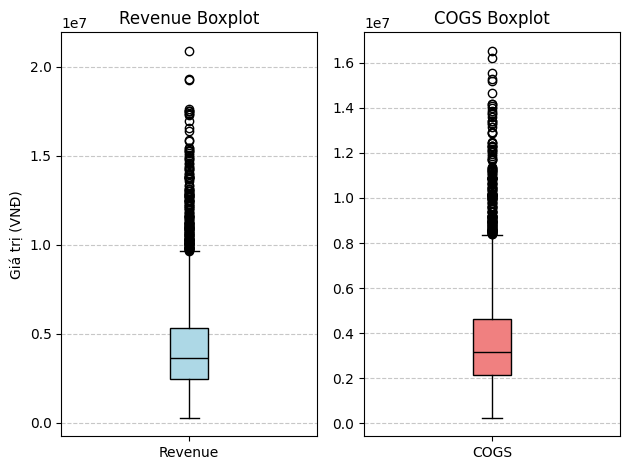

In [171]:
# Biểu đồ bên trái cho Revenue
plt.subplot(1, 2, 1)
plt.boxplot(sales['Revenue'], patch_artist=True, boxprops=dict(facecolor='lightblue'), medianprops={'color': 'black'})
plt.title('Revenue Boxplot')
plt.ylabel('Giá trị (VNĐ)')
plt.xticks([1], ['Revenue'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Biểu đồ bên phải cho COGS
plt.subplot(1, 2, 2)
plt.boxplot(sales['COGS'], patch_artist=True, boxprops=dict(facecolor='lightcoral'), medianprops={'color': 'black'})
plt.title('COGS Boxplot')
plt.xticks([1], ['COGS'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Căn chỉnh và lưu file
plt.tight_layout()
plt.savefig('../output/figures/sales_outliers_boxplot.png')
print("Biểu đồ sales_outliers_boxplot.png đã được tạo.")

In [172]:
outliers_sales, lb_sales, ub_sales = detect_outliers_iqr(sales, 'Revenue')
print(f"Số lượng outlier trong Revenue: {len(outliers_sales)}")
print(f"Ngưỡng trên: {ub_sales}")

Số lượng outlier trong Revenue: 169
Ngưỡng trên: 9670559.77


In [173]:
outliers_COGS, lb_COGS, ub_COGS = detect_outliers_iqr(sales, 'COGS')
print(f"Số lượng outlier trong COGS: {len(outliers_COGS)}")
print(f"Ngưỡng trên: {ub_COGS}")

Số lượng outlier trong COGS: 165
Ngưỡng trên: 8367364.455


Nhận xét:
- Cả 2 boxplot đều có phân phối lệch phải với median nằm gần đáy hộp, cho thấy phần lớn các ngày trong năm có doanh thu và chi phí thấp ổn định.
- Số lượng outlier của Revenue (169 ngày) và COGS (165 ngày) rất gần nhau, phản ánh tính nhất quán của dữ liệu — khi doanh thu tăng vọt, giá vốn tăng theo tương ứng, loại trừ khả năng doanh thu ảo.

-> Xử lý outlier: Đánh dấu flag, giữ nguyên các giá trị này phục vụ cho việc phân tích sau

In [174]:
sales['is_revenue_outlier'] = (sales['Revenue'] > ub_sales).astype(int)

sales['is_cogs_outlier'] = (sales['COGS'] > ub_COGS).astype(int)

### *Feature Engineering*

In [175]:
sales['year']        = pd.to_datetime(sales['Date']).dt.year
sales['month']       = pd.to_datetime(sales['Date']).dt.month
sales['quarter']     = pd.to_datetime(sales['Date']).dt.quarter
sales['day_of_week'] = pd.to_datetime(sales['Date']).dt.dayofweek
sales['is_weekend']  = (sales['day_of_week'] >= 5).astype(int)

# Gross profit (Lợi nhuận gộp) và margin (Biên lợi nhuận gộp)
sales['gross_profit'] = sales['Revenue'] - sales['COGS']
sales['gross_margin'] = sales['gross_profit'] / sales['Revenue']

- Các đặc trưng thời gian giúp nhận diện tính chu kỳ (Seasonality)
- Lợi nhuận gộp giúp xác định số tiền mặt thực tế còn lại.
- Biên lợi nhuận gộp cho biết mức độ sinh lời và hiệu quả quản lý chi phí.

### *Xuất file*

In [176]:
output_path = "../data/processed/pre_processed/sales_preprocessed.csv"
sales.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/sales_preprocessed.csv


# **4. Lớp Operational**

## **4.1. Inventory**

In [177]:
inventory.head()

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5


In [178]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60247 entries, 0 to 60246
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   snapshot_date      60247 non-null  object 
 1   product_id         60247 non-null  int64  
 2   stock_on_hand      60247 non-null  int64  
 3   units_received     60247 non-null  int64  
 4   units_sold         60247 non-null  int64  
 5   stockout_days      60247 non-null  int64  
 6   days_of_supply     60247 non-null  float64
 7   fill_rate          60247 non-null  float64
 8   stockout_flag      60247 non-null  int64  
 9   overstock_flag     60247 non-null  int64  
 10  reorder_flag       60247 non-null  int64  
 11  sell_through_rate  60247 non-null  float64
 12  product_name       60247 non-null  object 
 13  category           60247 non-null  object 
 14  segment            60247 non-null  object 
 15  year               60247 non-null  int64  
 16  month              602

- Không có giá trị null

### *Ép kiểu dữ liệu*

In [179]:
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

inventory['product_id'] = inventory['product_id'].astype(str)


### *Kiểm tra trùng lặp và logic*

In [180]:
assert inventory.duplicated().sum() == 0, "Có duplicate rows!"
assert inventory.duplicated(['snapshot_date', 'product_id']).sum() == 0, "Có duplicate (snapshot_date, product_id)!"
print("- Không có duplicate")

assert (inventory['stock_on_hand'] < 0).sum() == 0, "Có stock_on_hand < 0!"
assert (inventory['units_sold'] < 0).sum() == 0, "Có units_sold < 0!"
assert (inventory['units_received'] < 0).sum() == 0, "Có units_received < 0!"
assert (inventory['stockout_days'] < 0).sum() == 0, "Có stockout_days < 0!"
assert (inventory['days_of_supply'] < 0).sum() == 0, "Có days_of_supply < 0!"
print("- Tất cả chỉ số số lượng >= 0")


- Không có duplicate
- Tất cả chỉ số số lượng >= 0


In [181]:
assert (inventory['fill_rate'] < 0).sum() == 0 and (inventory['fill_rate'] > 1).sum() == 0, "fill_rate ngoài khoảng [0,1]!"
assert (inventory['sell_through_rate'] < 0).sum() == 0 and (inventory['sell_through_rate'] > 1).sum() == 0, "sell_through_rate ngoài khoảng [0,1]!"
print("- fill_rate và sell_through_rate trong khoảng [0,1]")

for flag_col in ['stockout_flag', 'overstock_flag', 'reorder_flag']:
    assert inventory[flag_col].isin([0, 1]).all(), f"{flag_col} không phải 0/1!"
print("- Tất cả flag columns hợp lệ")

# stockout_days không vượt quá số ngày trong tháng
inventory['days_in_month'] = inventory['snapshot_date'].dt.days_in_month
assert (inventory['stockout_days'] > inventory['days_in_month']).sum() == 0, "Có stockout_days > số ngày trong tháng!"
inventory = inventory.drop(columns=['days_in_month'])
print("- stockout_days không vượt số ngày trong tháng")

# year/month khớp snapshot_date
assert (inventory['year'] != inventory['snapshot_date'].dt.year).sum() == 0, "year không khớp snapshot_date!"
assert (inventory['month'] != inventory['snapshot_date'].dt.month).sum() == 0, "month không khớp snapshot_date!"
print("- year/month khớp snapshot_date")

- fill_rate và sell_through_rate trong khoảng [0,1]
- Tất cả flag columns hợp lệ
- stockout_days không vượt số ngày trong tháng
- year/month khớp snapshot_date


### *Feature Engineering*

In [182]:
# Tính vòng quay hàng tồn kho, cộng với 1e-5 để tránh lỗi chia cho 0
inventory['inventory_turnover'] = (inventory['units_sold'] / (inventory['stock_on_hand'] + 1e-5))

- Chỉ số này giúp quản lý chuỗi cung ứng nhận diện ngay lập tức các mặt hàng đang bị ứ đọng vốn (Turnover cực thấp) hoặc đang có nguy cơ cháy kho (Turnover cực cao)

### *Xuất file*

In [183]:
output_path = "../data/processed/pre_processed/inventory_preprocessed.csv"
inventory.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/inventory_preprocessed.csv


## **4.2. Web_traffic**

In [184]:
web_traffic.head()

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search
1,2013-01-02,10456,8151,47611,0.00406,120.5,organic_search
2,2013-01-03,10076,7458,36963,0.00401,263.6,direct
3,2013-01-04,9973,8063,53078,0.00562,151.8,direct
4,2013-01-05,10223,7882,36790,0.00525,168.6,referral


In [185]:
web_traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      3652 non-null   object 
 1   sessions                  3652 non-null   int64  
 2   unique_visitors           3652 non-null   int64  
 3   page_views                3652 non-null   int64  
 4   bounce_rate               3652 non-null   float64
 5   avg_session_duration_sec  3652 non-null   float64
 6   traffic_source            3652 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 199.8+ KB


- Không có giá trị null

### *Ép kiểu dữ liệu*

In [186]:
web_traffic['date'] = pd.to_datetime(web_traffic['date'])

### *Kiểm tra giá trị trùng lặp và lỗi logic*

In [187]:
assert web_traffic.duplicated().sum() == 0, "Có duplicate rows!"
assert web_traffic.duplicated('date').sum() == 0, "Có duplicate date!"
print("- Không có duplicate")

assert (web_traffic['sessions'] <= 0).sum() == 0, "Có sessions <= 0!"
assert (web_traffic['unique_visitors'] <= 0).sum() == 0, "Có unique_visitors <= 0!"
assert (web_traffic['page_views'] <= 0).sum() == 0, "Có page_views <= 0!"
print("- Tất cả sessions, unique_visitors, page_views > 0")

assert (web_traffic['bounce_rate'] < 0).sum() == 0 and (web_traffic['bounce_rate'] > 1).sum() == 0, "bounce_rate ngoài [0,1]!"
print("- bounce_rate trong khoảng [0,1]")

assert (web_traffic['avg_session_duration_sec'] < 0).sum() == 0, "Có avg_session_duration_sec < 0!"
print("- avg_session_duration_sec >= 0")

# unique_visitors không thể vượt sessions
assert (web_traffic['unique_visitors'] > web_traffic['sessions']).sum() == 0, "Có unique_visitors > sessions!"
print("- unique_visitors <= sessions")

# Chuỗi thời gian liên tục
full_range   = pd.date_range(web_traffic['date'].min(), web_traffic['date'].max())
missing_days = full_range.difference(web_traffic['date'])
assert len(missing_days) == 0, f"Có {len(missing_days)} ngày bị thiếu!"
print("- Chuỗi thời gian liên tục, không có ngày bị thiếu")

- Không có duplicate
- Tất cả sessions, unique_visitors, page_views > 0
- bounce_rate trong khoảng [0,1]
- avg_session_duration_sec >= 0
- unique_visitors <= sessions
- Chuỗi thời gian liên tục, không có ngày bị thiếu


### *Kiểm tra Outlier*

In [188]:
outliers_sessions, lb_sessions, ub_session = detect_outliers_iqr(web_traffic, 'sessions')

n_outliers = (web_traffic['sessions'] > ub_session).sum()
print(f"- sessions outlier: {n_outliers} dòng")

- sessions outlier: 0 dòng


- Không có các phiên truy cập bất thường

### *Feature Engineering*

In [189]:
# Pages per session — mức độ engagement
web_traffic['pages_per_session'] = (web_traffic['page_views'] / web_traffic['sessions']).round(2)

- biến `page_per_session`: Đây là thước đo mức độ gắn kết (Engagement). Nếu thấy doanh thu giảm ở một vùng nào đó, hãy kiểm tra cột này. Nếu khách vào rồi ra ngay (Pages per session thấp), chứng tỏ giao diện web hoặc sản phẩm ở vùng đó không hấp dẫn

### *Xuất file*

In [190]:
output_path = "../data/processed/pre_processed/web_traffic_preprocessed.csv"
web_traffic.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Đã lưu file: {output_path}")

Đã lưu file: ../data/processed/pre_processed/web_traffic_preprocessed.csv
